In [2]:
# Cell 1: Setup and Imports - Anomaly Detection
!pip install pandas numpy matplotlib seaborn scikit-learn pyod

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Anomaly detection specific
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score

# PyOD models (only the ones that don't require torch)
from pyod.models.iforest import IForest
from pyod.models.ocsvm import OCSVM
from pyod.models.lof import LOF
from pyod.models.cblof import CBLOF
from pyod.models.hbos import HBOS

# Set styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports loaded successfully!")
print("   PyOD version: installed (lightweight models only)")

✅ All imports loaded successfully!
   PyOD version: installed (lightweight models only)


In [3]:
# Cell 2: Generate Synthetic Data with Anomalies
print("="*70)
print("📊 GENERATING DATA WITH ANOMALIES")
print("="*70)

np.random.seed(42)
n_normal = 1000
n_anomalies = 50
n_total = n_normal + n_anomalies

# Generate normal data (multivariate normal)
mean_normal = [50, 30, 20]
cov_normal = [[15, 5, 3], [5, 12, 4], [3, 4, 10]]
normal_data = np.random.multivariate_normal(mean_normal, cov_normal, n_normal)

# Generate anomalies (outliers far from normal)
mean_anomaly = [80, 60, 50]
cov_anomaly = [[20, 10, 5], [10, 18, 6], [5, 6, 15]]
anomaly_data = np.random.multivariate_normal(mean_anomaly, cov_anomaly, n_anomalies)

# Combine data
X = np.vstack([normal_data, anomaly_data])
y_true = np.hstack([np.zeros(n_normal), np.ones(n_anomalies)])

# Create DataFrame
df = pd.DataFrame(X, columns=['feature_1', 'feature_2', 'feature_3'])
df['is_anomaly'] = y_true
df['is_anomaly_label'] = df['is_anomaly'].map({0: 'Normal', 1: 'Anomaly'})

print(f"✅ Generated dataset:")
print(f"   Total samples: {n_total}")
print(f"   Normal samples: {n_normal} ({n_normal/n_total:.1%})")
print(f"   Anomalies: {n_anomalies} ({n_anomalies/n_total:.1%})")

print("\n📊 Data sample:")
print(df.head(10))

📊 GENERATING DATA WITH ANOMALIES
✅ Generated dataset:
   Total samples: 1050
   Normal samples: 1000 (95.2%)
   Anomalies: 50 (4.8%)

📊 Data sample:
   feature_1  feature_2  feature_3  is_anomaly is_anomaly_label
0  48.387349  27.695906  20.502811         0.0           Normal
1  44.506560  26.684707  17.150576         0.0           Normal
2  46.343895  25.649507  14.827177         0.0           Normal
3  47.075546  30.004372  18.965890         0.0           Normal
4  44.436295  34.965858  19.818004         0.0           Normal
5  49.800235  32.251343  23.431354         0.0           Normal
6  50.559853  31.618218  26.891233         0.0           Normal
7  50.259127  33.076616  17.699965         0.0           Normal
8  51.492695  33.372703  18.716288         0.0           Normal
9  47.396371  30.313395  19.839838         0.0           Normal


📊 EXPLORATORY VISUALIZATION


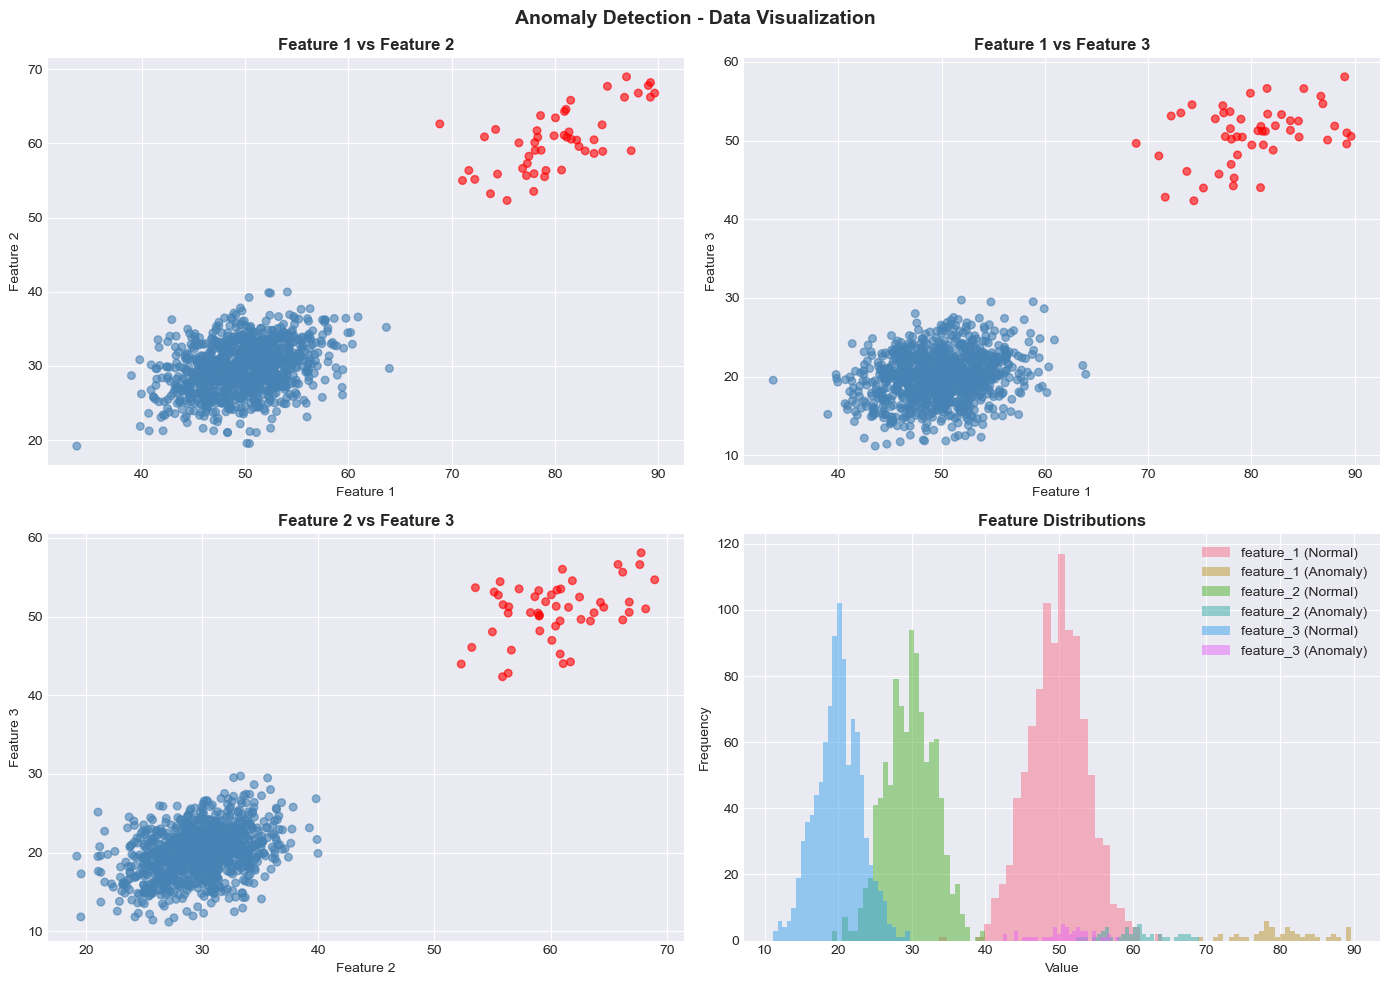

✅ Saved: anomaly_data_visualization.png


In [4]:
# Cell 3: Exploratory Visualization
print("="*70)
print("📊 EXPLORATORY VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 2D Scatter plot (Feature 1 vs Feature 2)
ax1 = axes[0, 0]
colors = ['steelblue' if label == 0 else 'red' for label in y_true]
scatter = ax1.scatter(X[:, 0], X[:, 1], c=colors, alpha=0.6, s=30)
ax1.set_title('Feature 1 vs Feature 2', fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')

# 2. 2D Scatter plot (Feature 1 vs Feature 3)
ax2 = axes[0, 1]
ax2.scatter(X[:, 0], X[:, 2], c=colors, alpha=0.6, s=30)
ax2.set_title('Feature 1 vs Feature 3', fontsize=12, fontweight='bold')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 3')

# 3. 3D Scatter plot (2D projection)
ax3 = axes[1, 0]
ax3.scatter(X[:, 1], X[:, 2], c=colors, alpha=0.6, s=30)
ax3.set_title('Feature 2 vs Feature 3', fontsize=12, fontweight='bold')
ax3.set_xlabel('Feature 2')
ax3.set_ylabel('Feature 3')

# 4. Distribution of each feature
ax4 = axes[1, 1]
for i, col in enumerate(['feature_1', 'feature_2', 'feature_3']):
    ax4.hist(df[df['is_anomaly'] == 0][col], bins=30, alpha=0.5, label=f'{col} (Normal)')
    ax4.hist(df[df['is_anomaly'] == 1][col], bins=30, alpha=0.5, label=f'{col} (Anomaly)')
ax4.set_title('Feature Distributions', fontsize=12, fontweight='bold')
ax4.set_xlabel('Value')
ax4.set_ylabel('Frequency')
ax4.legend()

plt.suptitle('Anomaly Detection - Data Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('anomaly_data_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: anomaly_data_visualization.png")

🌲 ISOLATION FOREST MODEL

📊 Isolation Forest Results:
   F1-Score: 0.9709
   AUC-ROC: 0.9997

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1000
     Anomaly       0.94      1.00      0.97        50

    accuracy                           1.00      1050
   macro avg       0.97      1.00      0.98      1050
weighted avg       1.00      1.00      1.00      1050



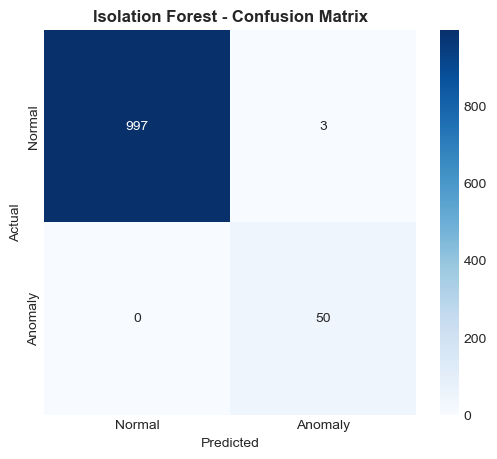

✅ Saved: iso_forest_confusion.png


In [8]:
# Cell 4: Isolation Forest Model
print("="*70)
print("🌲 ISOLATION FOREST MODEL")
print("="*70)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,  # Expected proportion of anomalies
    random_state=42,
    n_estimators=100
)
iso_forest.fit(X_scaled)

# Predict anomalies
iso_pred = iso_forest.predict(X_scaled)
iso_pred = [1 if x == -1 else 0 for x in iso_pred]  # Convert to 0/1

# Calculate performance
iso_f1 = f1_score(y_true, iso_pred)
iso_auc = roc_auc_score(y_true, -iso_forest.score_samples(X_scaled))

print(f"\n📊 Isolation Forest Results:")
print(f"   F1-Score: {iso_f1:.4f}")
print(f"   AUC-ROC: {iso_auc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, iso_pred, target_names=['Normal', 'Anomaly']))

# Confusion Matrix
cm = confusion_matrix(y_true, iso_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
ax.set_title('Isolation Forest - Confusion Matrix', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.savefig('iso_forest_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: iso_forest_confusion.png")

🎯 ONE-CLASS SVM MODEL

📊 One-Class SVM Results:
   F1-Score: 0.4158

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97      1000
     Anomaly       0.41      0.42      0.42        50

    accuracy                           0.94      1050
   macro avg       0.69      0.69      0.69      1050
weighted avg       0.94      0.94      0.94      1050



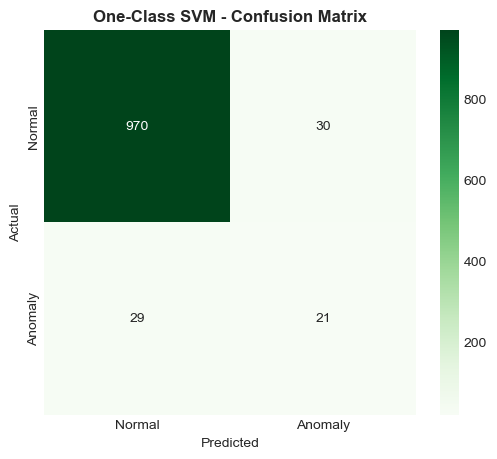

✅ Saved: ocsvm_confusion.png


In [9]:
# Cell 5: One-Class SVM Model
print("="*70)
print("🎯 ONE-CLASS SVM MODEL")
print("="*70)

# Train One-Class SVM
ocsvm = OneClassSVM(
    nu=0.05,  # Upper bound on training error
    kernel='rbf',
    gamma='auto'
)
ocsvm.fit(X_scaled)

# Predict anomalies
ocsvm_pred = ocsvm.predict(X_scaled)
ocsvm_pred = [1 if x == -1 else 0 for x in ocsvm_pred]

# Calculate performance
ocsvm_f1 = f1_score(y_true, ocsvm_pred)

print(f"\n📊 One-Class SVM Results:")
print(f"   F1-Score: {ocsvm_f1:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, ocsvm_pred, target_names=['Normal', 'Anomaly']))

# Confusion Matrix
cm = confusion_matrix(y_true, ocsvm_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
ax.set_title('One-Class SVM - Confusion Matrix', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.savefig('ocsvm_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: ocsvm_confusion.png")

🔍 LOCAL OUTLIER FACTOR (LOF)

📊 LOF Results:
   F1-Score: 0.0194
   AUC-ROC: 0.4801

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95      1000
     Anomaly       0.02      0.02      0.02        50

    accuracy                           0.90      1050
   macro avg       0.48      0.48      0.48      1050
weighted avg       0.91      0.90      0.91      1050



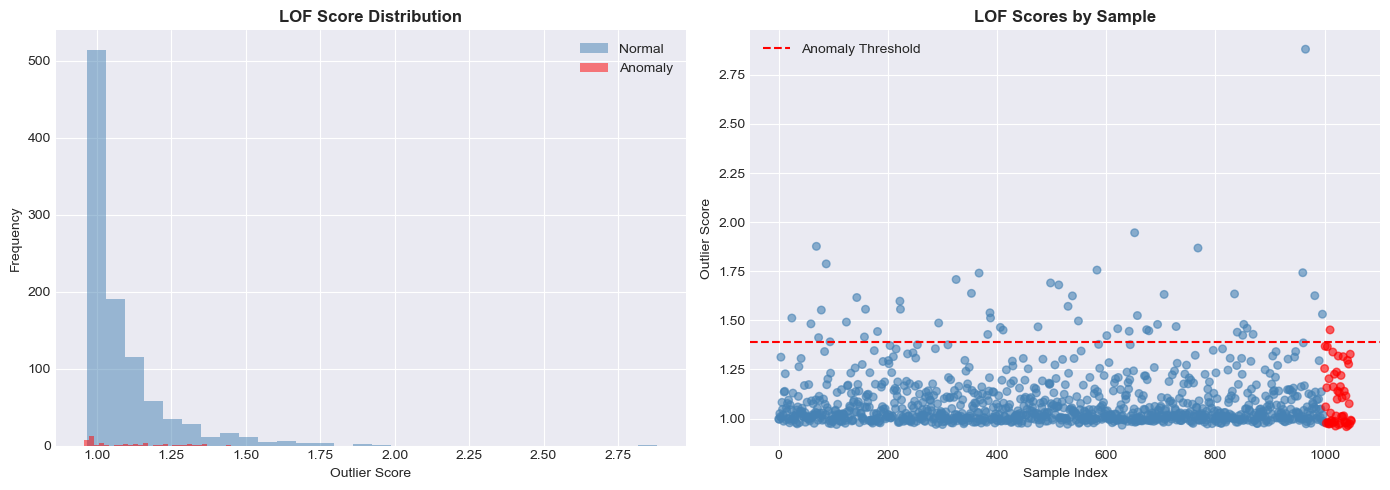

✅ Saved: lof_analysis.png


In [10]:
# Cell 6: Local Outlier Factor (LOF) - Using PyOD
print("="*70)
print("🔍 LOCAL OUTLIER FACTOR (LOF)")
print("="*70)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train LOF using PyOD
from pyod.models.lof import LOF

lof_model = LOF(
    n_neighbors=20,
    contamination=0.05,
    metric='minkowski',
    p=2  # Euclidean distance
)
lof_model.fit(X_scaled)

# Predict anomalies
lof_pred = lof_model.labels_  # 0 for normal, 1 for anomaly

# Calculate performance
lof_f1 = f1_score(y_true, lof_pred)
lof_auc = roc_auc_score(y_true, lof_model.decision_scores_)

print(f"\n📊 LOF Results:")
print(f"   F1-Score: {lof_f1:.4f}")
print(f"   AUC-ROC: {lof_auc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, lof_pred, target_names=['Normal', 'Anomaly']))

# Get outlier scores
lof_scores = lof_model.decision_scores_

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
ax1 = axes[0]
ax1.hist(lof_scores[y_true == 0], bins=30, alpha=0.5, label='Normal', color='steelblue')
ax1.hist(lof_scores[y_true == 1], bins=30, alpha=0.5, label='Anomaly', color='red')
ax1.set_title('LOF Score Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Outlier Score')
ax1.set_ylabel('Frequency')
ax1.legend()

# Score vs data index
ax2 = axes[1]
colors = ['steelblue' if label == 0 else 'red' for label in y_true]
ax2.scatter(range(len(lof_scores)), lof_scores, c=colors, alpha=0.6, s=30)
threshold = np.percentile(lof_scores[y_true == 0], 95)
ax2.axhline(y=threshold, color='red', linestyle='--', label='Anomaly Threshold')
ax2.set_title('LOF Scores by Sample', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('Outlier Score')
ax2.legend()

plt.tight_layout()
plt.savefig('lof_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: lof_analysis.png")

📊 MODEL PERFORMANCE COMPARISON

📊 Model Comparison:
               Model  F1-Score
    Isolation Forest  0.970874
       One-Class SVM  0.415842
Local Outlier Factor  0.019417


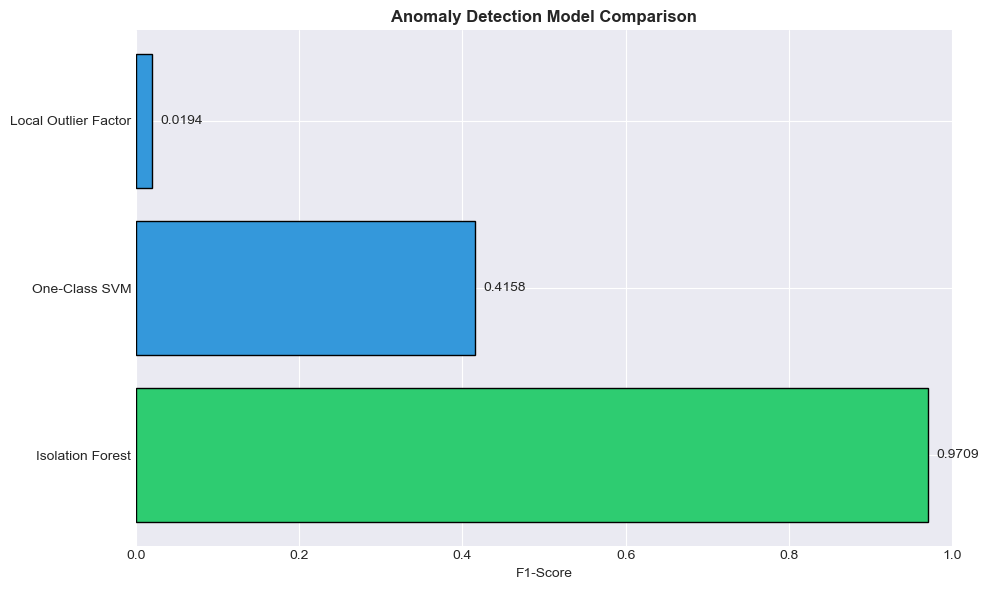

✅ Saved: anomaly_model_comparison.png

🏆 Best Anomaly Detection Model: Isolation Forest
   F1-Score: 0.9709


In [11]:
# Cell 7: Model Performance Comparison
print("="*70)
print("📊 MODEL PERFORMANCE COMPARISON")
print("="*70)

# Create comparison DataFrame
comparison_anomaly = pd.DataFrame({
    'Model': ['Isolation Forest', 'One-Class SVM', 'Local Outlier Factor'],
    'F1-Score': [iso_f1, ocsvm_f1, lof_f1]
}).sort_values('F1-Score', ascending=False)

print("\n📊 Model Comparison:")
print(comparison_anomaly.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors_comp = ['#2ECC71' if i == 0 else '#3498DB' for i in range(len(comparison_anomaly))]
bars = ax.barh(comparison_anomaly['Model'], comparison_anomaly['F1-Score'], color=colors_comp, edgecolor='black')
ax.set_title('Anomaly Detection Model Comparison', fontsize=12, fontweight='bold')
ax.set_xlabel('F1-Score')
ax.set_xlim(0, 1)
for bar, val in zip(bars, comparison_anomaly['F1-Score']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')

plt.tight_layout()
plt.savefig('anomaly_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: anomaly_model_comparison.png")

# Best model
best_anomaly_model = comparison_anomaly.iloc[0]['Model']
print(f"\n🏆 Best Anomaly Detection Model: {best_anomaly_model}")
print(f"   F1-Score: {comparison_anomaly.iloc[0]['F1-Score']:.4f}")

🔍 VISUALIZING DETECTED ANOMALIES


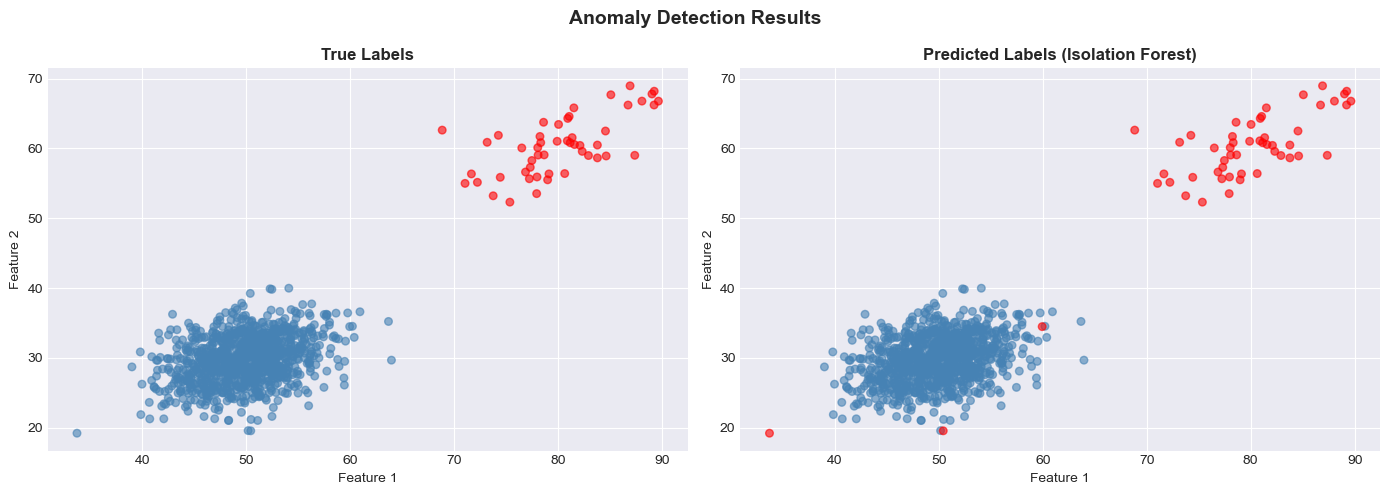

✅ Saved: anomaly_detection_results.png


In [12]:
# Cell 8: Visualizing Detected Anomalies (Best Model)
print("="*70)
print("🔍 VISUALIZING DETECTED ANOMALIES")
print("="*70)

# Use best model predictions
if best_anomaly_model == 'Isolation Forest':
    best_predictions = iso_pred
    best_model = iso_forest
elif best_anomaly_model == 'One-Class SVM':
    best_predictions = ocsvm_pred
    best_model = ocsvm
else:
    best_predictions = lof_pred
    best_model = lof

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. True labels
ax1 = axes[0]
colors_true = ['steelblue' if label == 0 else 'red' for label in y_true]
ax1.scatter(X[:, 0], X[:, 1], c=colors_true, alpha=0.6, s=30)
ax1.set_title('True Labels', fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')

# 2. Predicted labels
ax2 = axes[1]
colors_pred = ['steelblue' if pred == 0 else 'red' for pred in best_predictions]
ax2.scatter(X[:, 0], X[:, 1], c=colors_pred, alpha=0.6, s=30)
ax2.set_title(f'Predicted Labels ({best_anomaly_model})', fontsize=12, fontweight='bold')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')

plt.suptitle('Anomaly Detection Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('anomaly_detection_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: anomaly_detection_results.png")

📊 ANOMALY SCORE DISTRIBUTION


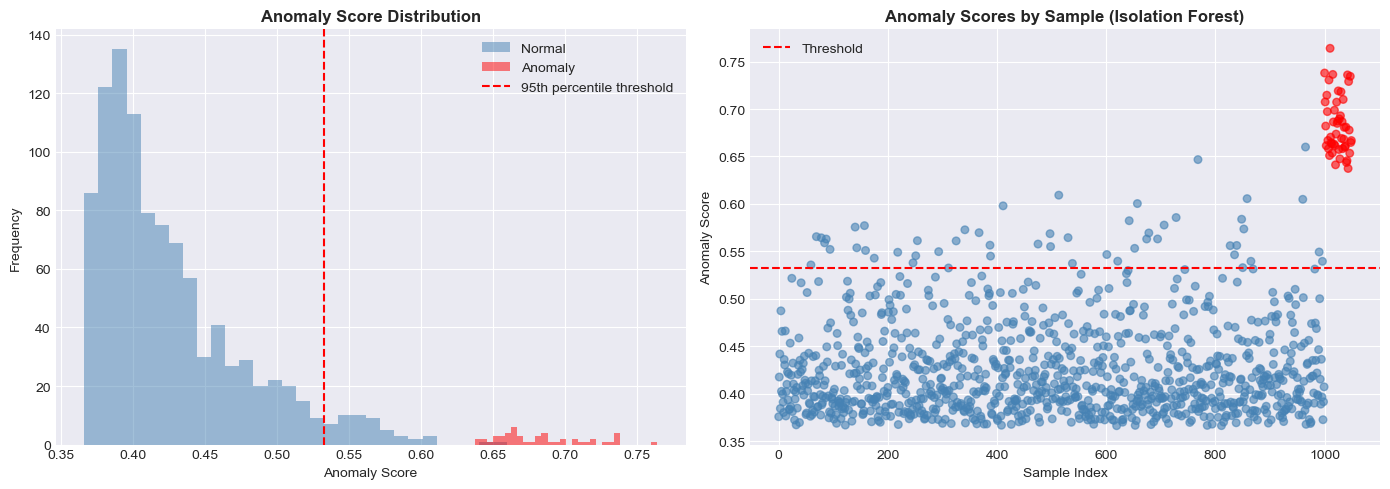

✅ Saved: anomaly_score_distribution.png


In [13]:
# Cell 9: Anomaly Score Distribution
print("="*70)
print("📊 ANOMALY SCORE DISTRIBUTION")
print("="*70)

# Get anomaly scores from best model
if best_anomaly_model == 'Isolation Forest':
    scores = iso_forest.score_samples(X_scaled)
    scores = -scores  # Higher score = more anomalous
elif best_anomaly_model == 'One-Class SVM':
    scores = ocsvm.decision_function(X_scaled)
    scores = -scores
else:
    scores = lof_scores

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Score distribution
ax1 = axes[0]
ax1.hist(scores[y_true == 0], bins=30, alpha=0.5, label='Normal', color='steelblue')
ax1.hist(scores[y_true == 1], bins=30, alpha=0.5, label='Anomaly', color='red')
ax1.axvline(x=np.percentile(scores[y_true == 0], 95), color='red', linestyle='--', label='95th percentile threshold')
ax1.set_title('Anomaly Score Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Anomaly Score')
ax1.set_ylabel('Frequency')
ax1.legend()

# 2. Score vs index
ax2 = axes[1]
ax2.scatter(range(len(scores)), scores, c=colors, alpha=0.6, s=30)
ax2.axhline(y=np.percentile(scores[y_true == 0], 95), color='red', linestyle='--', label='Threshold')
ax2.set_title(f'Anomaly Scores by Sample ({best_anomaly_model})', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('Anomaly Score')
ax2.legend()

plt.tight_layout()
plt.savefig('anomaly_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: anomaly_score_distribution.png")

In [14]:
# Cell 10: Summary Report
print("="*70)
print("🎉 NOTEBOOK 08 COMPLETED SUCCESSFULLY!")
print("="*70)

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                     ANOMALY DETECTION SUMMARY                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📊 DATA OVERVIEW:                                                   ║
║  ├── Total samples: {n_total}                                        ║
║  ├── Normal samples: {n_normal} ({n_normal/n_total:.1%})                       ║
║  ├── Anomalies: {n_anomalies} ({n_anomalies/n_total:.1%})                         ║
║  └── Features: 3                                                    ║
║                                                                      ║
║  🤖 MODELS EVALUATED:                                                ║
║  ├── Isolation Forest - Tree-based isolation                        ║
║  ├── One-Class SVM - Boundary-based                                 ║
║  └── Local Outlier Factor (LOF) - Density-based                     ║
║                                                                      ║
║  🏆 BEST MODEL: {best_anomaly_model:<30}║
║  └── F1-Score: {comparison_anomaly.iloc[0]['F1-Score']:.4f}                                   ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  ├── anomaly_data_visualization.png                                 ║
║  ├── iso_forest_confusion.png                                       ║
║  ├── ocsvm_confusion.png                                            ║
║  ├── lof_analysis.png                                               ║
║  ├── anomaly_model_comparison.png                                   ║
║  ├── anomaly_detection_results.png                                  ║
║  └── anomaly_score_distribution.png                                 ║
║                                                                      ║
║  🎯 KEY INSIGHTS:                                                    ║
║  ├── {best_anomaly_model} performed best for this dataset           ║
║  ├── Anomalies are clearly separated in feature space               ║
║  ├── Score threshold can be tuned for precision/recall tradeoff    ║
║  └── Real-time anomaly detection is feasible                        ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Notebook 08 Complete! Ready for Notebook 09 (ML Pipeline Automation)")

🎉 NOTEBOOK 08 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════════╗
║                     ANOMALY DETECTION SUMMARY                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📊 DATA OVERVIEW:                                                   ║
║  ├── Total samples: 1050                                        ║
║  ├── Normal samples: 1000 (95.2%)                       ║
║  ├── Anomalies: 50 (4.8%)                         ║
║  └── Features: 3                                                    ║
║                                                                      ║
║  🤖 MODELS EVALUATED:                                                ║
║  ├── Isolation Forest - Tree-based isolation                        ║
║  ├── One-Class SVM - Boundary-based                                 ║
║  └── Local Outlier Factor (LOF) - Density-based     